## TC 5033
### Text Classifier with RNNs

<br>

#### Activity 3b: Text Classification using RNNs and AG_NEWS dataset in PyTorch
<br>

- Objective:
    - Understand the basics of Recurrent Neural Networks (RNNs) and their application in text classification.
    - Learn how to handle a real-world text dataset, AG_NEWS, in PyTorch.
    - Gain hands-on experience in defining, training, and evaluating a text classification model in PyTorch.
    
<br>

- Instructions:
    - Data Preparation: Starter code will be provided that loads the AG_NEWS dataset and prepares it for training. Do not modify this part. However, you should be sure to understand it, and comment it, the use of markdown cells is suggested.

    - Model Setup: A skeleton code for the RNN model class will be provided. Complete this class and use it to instantiate your model.

    - Implementing Accuracy Function: Write a function that takes model predictions and ground truth labels as input and returns the model's accuracy.

    - Training Function: Implement a function that performs training on the given model using the AG_NEWS dataset. Your model should achieve an accuracy of at least 80% to get full marks for this part.

    - Text Sampling: Write a function that takes a sample text as input and classifies it using your trained model.

    - Confusion Matrix: Implement a function to display the confusion matrix for your model on the test data.

    - Submission: Submit your completed Jupyter Notebook. Make sure to include a markdown cell at the beginning of the notebook that lists the names of all team members. Teams should consist of 3 to 4 members.
    
<br>

- Evaluation Criteria:

    - Correct setup of all the required libraries and modules (10%)
    - Code Quality (30%): Your code should be well-organized, clearly commented, and easy to follow. Use also markdown cells for clarity. Comments should be given for all the provided code, this will help you understand its functionality.
    
   - Functionality (60%):
        - All the functions should execute without errors and provide the expected outputs.
        - RNN model class (20%)
        - Accuracy fucntion (10%)
        - Training function (10%)
        - Sampling function (10%)
        - Confucion matrix (10%)

        - The model should achieve at least an 80% accuracy on the AG_NEWS test set for full marks in this criterion.


**Team 30**

A01796272 - Luis Antonio Ramirez Martinez

A01796323 - Benjamin Cisneros Barraza

A01796363 - Arthur Jafed Zizumbo Velasco

A01796937 - Sandra Luz Cervantes Espinoza

Dataset

https://pytorch.org/text/stable/datasets.html#text-classification

https://paperswithcode.com/dataset/ag-news


#### Install libraries (if needed)

You may need to install the following libraries, also you may need to adjust library versions to ensure compatibility, depending on the versions you have previously installed. After installing them, please Restart the Session (Runtime -> Restart Session), or Kernel - Restart Kerne

In [1]:
!pip install torch==2.2.0 torchvision==0.17.0 torchaudio==2.2.0 torchtext==0.16.2

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 755.4/755.4 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.9/6.9 MB 131.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 120.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 107.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 87.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 69.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 56.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 14.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.

In [2]:
!pip install scipy==1.9.3
!pip install scikit-plot
#you may receive a message of restarting session, this is OK

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.1/42.1 MB 11.2 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Installing backend dependencies ... done
  error: subprocess-exited-with-error
  
  × Preparing metadata (pyproject.toml) did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (pyproject.toml) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.


In [4]:
!pip install portalocker
#please restar session after this intallation. After restarting go straight to importing the libraries

## Import libraries

In [6]:
# The following libraries are required for running the given code
# Please feel free to add any libraries you consider adecuate to complete the assingment.
import numpy as np
#PyTorch libraries
import torch
from torchtext.datasets import AG_NEWS
# Dataloader library
from torch.utils.data import DataLoader
from torch.utils.data.dataset import random_split
# Libraries to prepare the data
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from torchtext.data.functional import to_map_style_dataset
# neural layers
from torch import nn
from torch.nn import functional as F

# These libraries are suggested to plot confusion matrix
# you may use others
import scikitplot as skplt
import gc


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

In [7]:
# Use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


### Get the train and the test datasets and dataloaders

Classes:

* 1 - World

* 2 - Sports

* 3 - Business

* 4 - Sci/Tech

We will convert them to:

* 0 - World

* 1 - Sports

* 2 - Business

* 3 - Sci/Tech

In [10]:
train_dataset, test_dataset = AG_NEWS()
train_dataset, test_dataset = to_map_style_dataset(train_dataset), to_map_style_dataset(test_dataset)

In [11]:
# Get the tokeniser
# tokeniser object
tokeniser = get_tokenizer('basic_english')

def yield_tokens(data):
    for _, text in data:
        yield tokeniser(text)

In [12]:
# Build the vocabulary
vocab = build_vocab_from_iterator(yield_tokens(train_dataset), specials=["<unk>"])
#set unknown token at position 0
vocab.set_default_index(vocab["<unk>"])

In [13]:
#test tokens
tokens = tokeniser('Welcome to TC5033')
print(tokens, vocab(tokens))

['welcome', 'to', 'tc5033'] [3314, 4, 0]


In [14]:
NUM_TRAIN = int(len(train_dataset)*0.9)
NUM_VAL = len(train_dataset) - NUM_TRAIN

In [15]:
train_dataset, val_dataset = random_split(train_dataset, [NUM_TRAIN, NUM_VAL])

In [16]:
print(len(train_dataset), len(val_dataset), len(test_dataset))

108000 12000 7600


In [17]:
# function passed to the DataLoader to process a batch of data as indicated
def collate_batch(batch):
    # Get label and text
    y, x = list(zip(*batch))

    # Create list with indices from tokeniser
    x = [vocab(tokeniser(text)) for text in x]
    x = [t + ([0]*(max_tokens - len(t))) if len(t) < max_tokens else t[:max_tokens] for t in x]

    # Prepare the labels, by subtracting 1 to get them in the range 0-3
    return torch.tensor(x, dtype=torch.int32), torch.tensor(y, dtype=torch.int32) - 1

In [18]:
labels =  ["World", "Sports", "Business", "Sci/Tech"]
max_tokens = 50
BATCH_SIZE = 256

In [19]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, collate_fn=collate_batch, shuffle = True)

### Let us build our RNN model

In [20]:
EMBEDDING_SIZE = 300
NEURONS = 256
LAYERS = 2
NUM_CLASSES = 4

In [21]:
class RNN_Model_1(nn.Module):
    def __init__(self, embed_size, hidden, layers, num_classes):
        super().__init__()
        #Capa de Embedding, convierte IDs de palabras en vectores densos.
        self.embedding_layer = nn.Embedding(num_embeddings=len(vocab),
                                            embedding_dim=embed_size)

        # Capa Recurrente, se usa LSTM para evitar el desvanecimiento del gradiente.
        # batch_first=True es necesario porque tus datos vienen como [batch, seq].
        self.rnn = nn.LSTM(input_size=embed_size,
                           hidden_size=hidden,
                           num_layers=layers,
                           batch_first=True)

        # Clasificador, una capa lineal que mapea el estado oculto a las 4 clases.
        self.fc = nn.Linear(in_features=hidden,
                            out_features=num_classes)

    def forward(self, x):
        # x shape: [batch_size, sequence_length]

        # Obtener embeddings
        embedded = self.embedding_layer(x) # [batch, seq, embed_dim]

        #Pasar por la LSTM
        # output contiene todos los estados ocultos de la secuencia
        # hidden (h_n) contiene el estado oculto final de cada capa
        output, (h_n, c_n) = self.rnn(embedded)

        # se usa el último estado oculto de la última capa para clasificar
        # h_n shape: [num_layers, batch_size, hidden_size]
        last_hidden_state = h_n[-1]

        return self.fc(last_hidden_state)

In [22]:
def accuracy(model, loader):
    model.eval()
    correct = 0
    total = 0

    with torch.no_grad():
        for x, y in loader:
            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y).sum().item()
            total += y.size(0)

    return correct / total

In [23]:
def train(model, optimiser, epochs=10):
    criterion = torch.nn.CrossEntropyLoss()

    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for x, y in train_loader:

            # asegurar tipo correcto
            x = x.long()
            y = y.long()

            optimiser.zero_grad()

            outputs = model(x)
            loss = criterion(outputs, y)

            loss.backward()
            optimiser.step()

            total_loss += loss.item()

        print(f"Epoch {epoch+1}/{epochs} | Loss: {total_loss:.4f}")

In [26]:
epochs = 3
lr = 0.001
# instantiate model
rnn_model = RNN_Model_1(EMBEDDING_SIZE, NEURONS, LAYERS, NUM_CLASSES)
optimiser = torch.optim.Adam(rnn_model.parameters(), lr=lr)

In [27]:
train(rnn_model, optimiser=optimiser, epochs=epochs)

Epoch 1/3 | Loss: 265.5104
Epoch 2/3 | Loss: 120.7543
Epoch 3/3 | Loss: 88.3716


In [28]:
print(f'{accuracy(rnn_model, test_loader):.4f}')

0.9097


In [34]:
def sample_text(model, loader):

    device = next(model.parameters()).device
    model.eval()

    with torch.no_grad():
        for x, y in loader:

            x = x.to(device)
            y = y.to(device)

            outputs = model(x)
            preds = torch.argmax(outputs, dim=1)

            print("Predicción:", preds[0].item())
            print("Etiqueta real:", y[0].item())

            break

In [35]:
sample_text(rnn_model, test_loader)

Predicción: 3
Etiqueta real: 3


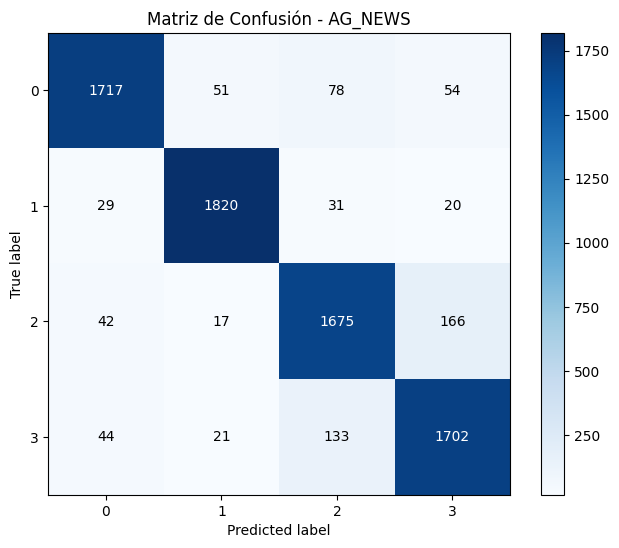

In [42]:
import matplotlib.pyplot as plt
import scikitplot as skplt

def plot_confusion_matrix(model, loader):

    device = next(model.parameters()).device
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for texts, labels in loader:

            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts)
            preds = outputs.argmax(dim=1)

            y_true.extend(labels.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

        skplt.metrics.plot_confusion_matrix(
            y_true,
            y_pred,
            figsize=(8,6),
            title="Matriz de Confusión - AG_NEWS"
        )

    plt.show()


plot_confusion_matrix(rnn_model, test_loader)

Métricas del modelo

In [43]:
from sklearn.metrics import classification_report
import torch

def evaluate_model(model, loader):

    device = next(model.parameters()).device
    model.eval()

    y_true = []
    y_pred = []

    with torch.no_grad():
        for texts, labels in loader:

            texts = texts.to(device)
            labels = labels.to(device)

            outputs = model(texts)
            preds = outputs.argmax(dim=1)

            y_true.extend(labels.cpu().tolist())
            y_pred.extend(preds.cpu().tolist())

    print(classification_report(
        y_true,
        y_pred,
        target_names=["World","Sports","Business","Sci/Tech"]
    ))


evaluate_model(rnn_model, test_loader)

              precision    recall  f1-score   support

       World       0.94      0.90      0.92      1900
      Sports       0.95      0.96      0.96      1900
    Business       0.87      0.88      0.88      1900
    Sci/Tech       0.88      0.90      0.89      1900

    accuracy                           0.91      7600
   macro avg       0.91      0.91      0.91      7600
weighted avg       0.91      0.91      0.91      7600



Predicciones del modelo

In [44]:
def show_predictions(model, loader, num_examples=5):

    device = next(model.parameters()).device
    model.eval()

    labels_map = ["World","Sports","Business","Sci/Tech"]

    with torch.no_grad():
        for texts, labels in loader:

            texts = texts.to(device)
            outputs = model(texts)
            preds = outputs.argmax(dim=1)

            for i in range(num_examples):

                print("Predicción:", labels_map[preds[i]])
                print("Real:", labels_map[labels[i]])
                print("-"*50)

            break


show_predictions(rnn_model, test_loader)

Predicción: Sports
Real: Sports
--------------------------------------------------
Predicción: World
Real: World
--------------------------------------------------
Predicción: Sports
Real: Sports
--------------------------------------------------
Predicción: World
Real: World
--------------------------------------------------
Predicción: World
Real: World
--------------------------------------------------
